# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tenuka-R/FlyRank-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Which underperforming content pages should be prioritized for a refresh, and how much click growth can theuy gain?
Content teams work on many more pages than they can refresh at a given time. This creates a large, messy pile of pages into a ranked and reasoned list so a team knows which pages are worth doing first and why.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

My project uses the FlyRank internship warehouse (Hugging Face dataset that has gated access and is pseudonymized) which contains search and content performance data collected through Google Search Console (GSC) and Google Analytics 4 (GA4)

The tables that I used were:
- fact_content_daily_performance: daily search performance metrics per content item, per client.
- dim_content: static content attributes

Date windows: The data spans Jaunary 2025 to June 2026 and the final month (June 2026) is used as a seperate test window and not for developing model logic.

Exclusions:
- I excluded rows where GSC data was unavailable as the metrics would be meaningless without it
- Query level data was not used so that I could keep a consistent grain (one content item and one time period) throughout the project.
- No real client names, domains or URLs appear anywhere in this work


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Assumptions:
- I assumed that a page's performance signals (such as position, CTR, staleness, etc.) for a given month can be used to predict if the page will lose or gain clicks in the next month.
- I assumed that for pages with very little search traffic (under 20 impressions), the CTR cannot be accurately predicted so there is a threshold for minimum CTR.
- Content attributes that do not change such as word count and content type are safe to be used as features as they are known before prediction.

Features:
- Average search position
- CTR (threshold is minimum 20 impressions)
- Total impressions
- Days since last content update
- Word count/content type

Label definition:
My chosen label is click growth which is the change in clicks for a page from month T to month T+1. It is therefore a forward looking label and features are taken from month T and the label is calculated using month T+1. The scores rank the items by expected opportunity from highest to lowest.

Baseline:
A hand written scoring rule which combines staleness, position and CTR gap into a score with weightage and includes a reason code and recommened action.

Validation design:
Validation uses a seperate month-pair that is not used in training so the model is tested on data from further in time than what it is trained on. Data of a content item is not split between training and validation to prevent leakage.

Leakage chceks:
Two leakage issues were found and fixed:
- A content-update-date column WRITE HERE NOT COMPLETE
- CTR calculated on pages with very low impression was fixed by adding a minimum threshold.

In [2]:
def load_month_features(month_str):
    fact = pd.read_parquet(
        f"hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month={month_str}/data_0.parquet",
        storage_options={"token": os.environ["HF_TOKEN"]}
    )
    avail = fact[fact["gsc_data_available"] == True].copy()
    avail["ctr"] = np.where(avail["gsc_impressions"] > 0, avail["gsc_clicks"] / avail["gsc_impressions"], np.nan)

    agg = avail.groupby(["client_hash_id", "content_hash_id"]).agg(
        total_clicks=("gsc_clicks", "sum"),
        total_impressions=("gsc_impressions", "sum"),
        avg_position=("gsc_avg_position", "mean"),
    ).reset_index()
    agg["ctr"] = np.where(agg["total_impressions"] > 0, agg["total_clicks"] / agg["total_impressions"], 0)
    agg["month"] = month_str
    return agg

content_dates = pd.read_parquet(
    "hf://datasets/FlyRank/internship-warehouse/dim_content.parquet",
    storage_options={"token": os.environ["HF_TOKEN"]},
    columns=["client_hash_id", "content_hash_id", "content_updated_date", "word_count", "content_type"]
)

month_cache = {}

def get_month_features(month_str):
    if month_str not in month_cache:
        month_cache[month_str] = load_month_features(month_str)
    return month_cache[month_str]

def build_pair_cached(month_t, month_t1):
    feat_t = get_month_features(month_t)
    feat_t1 = get_month_features(month_t1)

    merged = feat_t.merge(
        feat_t1[["client_hash_id", "content_hash_id", "total_clicks"]],
        on=["client_hash_id", "content_hash_id"], how="inner", suffixes=("", "_next")
    )
    merged = merged.merge(content_dates, on=["client_hash_id", "content_hash_id"], how="left")

    merged["report_date_proxy"] = pd.to_datetime(month_t + "-01")
    merged["content_updated_date"] = pd.to_datetime(merged["content_updated_date"], errors="coerce")
    merged["days_since_update"] = np.where(
        merged["content_updated_date"] <= merged["report_date_proxy"],
        (merged["report_date_proxy"] - merged["content_updated_date"]).dt.days,
        np.nan
    )
    merged["click_growth"] = merged["total_clicks_next"] - merged["total_clicks"]
    merged["pair_id"] = f"{month_t}->{month_t1}"
    return merged

all_clients = content_dates["client_hash_id"].unique()
rng = np.random.default_rng(seed=42)
rng.shuffle(all_clients)

n_val_clients = int(len(all_clients) * 0.2)
val_clients = set(all_clients[:n_val_clients])
train_clients = set(all_clients[n_val_clients:])

print("total clients:", len(all_clients))
print("train clients:", len(train_clients), "| val clients:", len(val_clients))

all_pairs = [
    ("2025-01","2025-02"), ("2025-02","2025-03"), ("2025-03","2025-04"),
    ("2025-04","2025-05"), ("2025-05","2025-06"), ("2025-06","2025-07"),
    ("2025-07","2025-08"), ("2025-08","2025-09"), ("2025-09","2025-10"),
    ("2025-10","2025-11"), ("2025-11","2025-12"), ("2025-12","2026-01"),
    ("2026-01","2026-02"), ("2026-02","2026-03"), ("2026-03","2026-04"),
    ("2026-04","2026-05")
]

all_frames = [build_pair_cached(t, t1) for t, t1 in all_pairs]
full_df = pd.concat(all_frames, ignore_index=True)

train_df = full_df[full_df["client_hash_id"].isin(train_clients)].copy()
val_df   = full_df[full_df["client_hash_id"].isin(val_clients)].copy()

print("train rows:", len(train_df), "| train clients:", train_df["client_hash_id"].nunique())
print("val rows:", len(val_df), "| val clients:", val_df["client_hash_id"].nunique())

overlap = set(train_df["client_hash_id"]) & set(val_df["client_hash_id"])
print("client overlap (should be 0):", len(overlap))

total clients: 84
train clients: 68 | val clients: 16
train rows: 690929 | train clients: 45
val rows: 307288 | val clients: 15
client overlap (should be 0): 0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [3]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

feature_cols = ["avg_position", "ctr", "total_impressions", "days_since_update", "word_count"]

X_train = train_df[feature_cols].fillna(0)
y_train = train_df["click_growth"].fillna(0)

X_val = val_df[feature_cols].fillna(0)
y_val = val_df["click_growth"].fillna(0)

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

val_df = val_df.copy()
val_df["predicted_growth"] = model.predict(X_val)

mae = mean_absolute_error(y_val, val_df["predicted_growth"])
print("Model MAE on validation:", mae)
print(val_df[["content_hash_id","avg_position","ctr","total_impressions","days_since_update","click_growth","predicted_growth"]].sort_values("predicted_growth", ascending=False).head(10))

print(val_df["click_growth"].describe())

val_df["ctr_gap_score"] = np.where(val_df["total_impressions"] >= 20, 1 - val_df["ctr"].fillna(0), 0)
val_df["staleness_score"] = (val_df["days_since_update"].fillna(0) / 365).clip(0, 1)
val_df["position_score"] = (1 - (val_df["avg_position"].fillna(100) / 100).clip(0, 1))
val_df["baseline_score"] = val_df["staleness_score"]*40 + val_df["position_score"]*30 + val_df["ctr_gap_score"]*30

def precision_at_k(df, score_col, k=20, growth_threshold=0):
    top_k = df.sort_values(score_col, ascending=False).head(k)
    return (top_k["click_growth"] > growth_threshold).mean()

print("Baseline precision@20:", precision_at_k(val_df, "baseline_score"))
print("Model precision@20:", precision_at_k(val_df, "predicted_growth"))
print("Baseline precision@20 (5+ clicks):", precision_at_k(val_df, "baseline_score", growth_threshold=5))
print("Model precision@20 (5+ clicks):", precision_at_k(val_df, "predicted_growth", growth_threshold=5))
print("Baseline precision@10:", precision_at_k(val_df, "baseline_score", k=10))
print("Model precision@10:", precision_at_k(val_df, "predicted_growth", k=10))
print("Baseline precision@10 (5+ clicks):", precision_at_k(val_df, "baseline_score", k=10, growth_threshold=5))
print("Model precision@10 (5+ clicks):", precision_at_k(val_df, "predicted_growth", k=10, growth_threshold=5))

Model MAE on validation: 2.318373172540471
                 content_hash_id  avg_position       ctr  total_impressions  \
676176  content_2db2a9dcb3b62a3a      2.554614  0.019350            23876.0   
903330  content_765403788e6d6813      3.778684  0.019838            29792.0   
676426  content_5ebc94f67db6f51c      2.702855  0.019705            21923.0   
817248  content_1516ec061fe1f8a5      4.698160  0.019911            51428.0   
838252  content_3084163349f42c00      5.702521  0.004597            95275.0   
523403  content_1516ec061fe1f8a5      6.705953  0.021046            38962.0   
184240  content_46865bde5de43b83      6.096600  0.002566             3897.0   
577387  content_146b99a9084a3b5b      6.096599  0.000000              217.0   
532936  content_b749d6a6ae61112b      6.096590  0.007718            34077.0   
912087  content_ca3299d86449ea37      1.535163  0.000391           109923.0   

        days_since_update  click_growth  predicted_growth  
676176                NaN  

## 5. Limitations

*What this work cannot claim.*

This work does not claim that refresing a page in the ranking will cause it's clicks to grow. It only suggests that pages with certain characteristics such as position, CTR gap, staleness have a better chance of gaining clicks than others - based on an observed correlation.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

1. Use the model's score to priorise what to refresh first
2. Use the top 10 as the highest confidence picks
3. Each page in the output should have at least 20 monthly impressions before looking at other signals
4. Be careful with the staleness as the update date might not be reliable
5. Perform occasional validation tests as performance may change over time
6. Along with the score, take consideration of the reason code for each recommendation

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

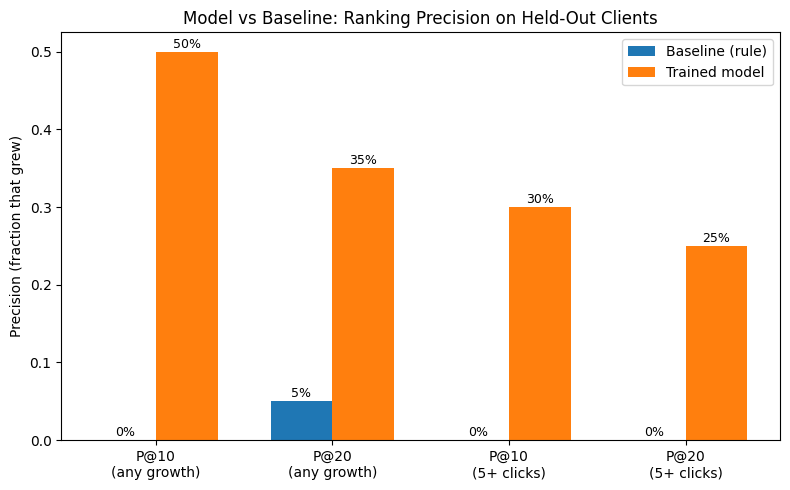

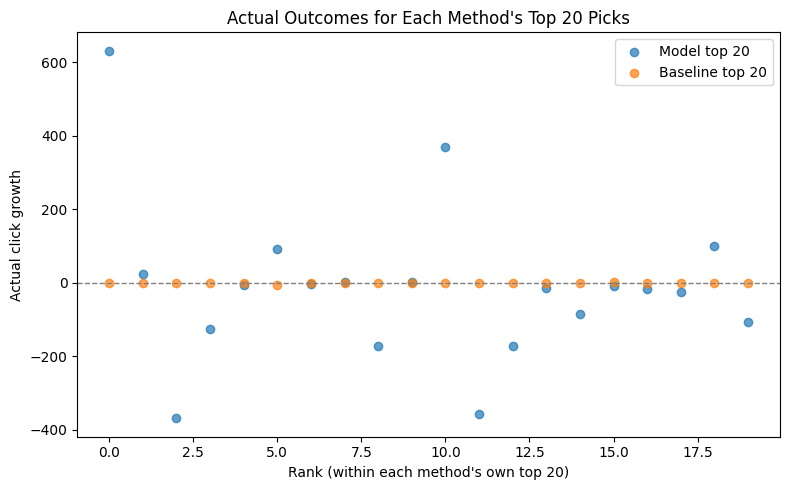

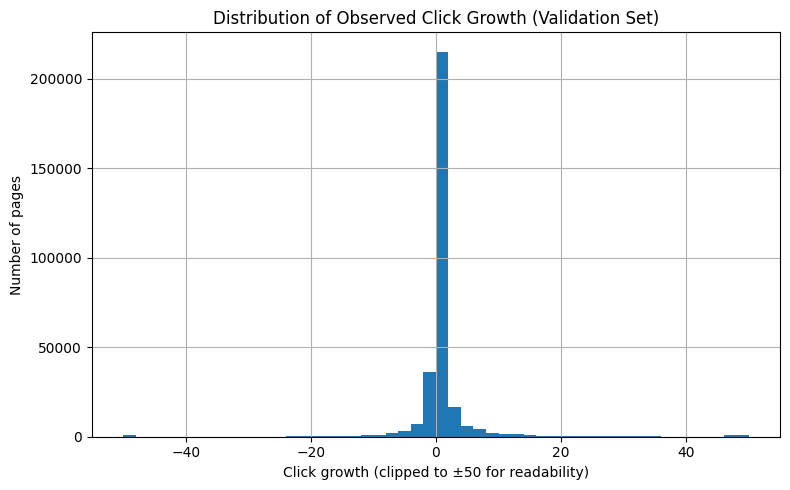

In [6]:
import matplotlib.pyplot as plt

metrics = ["P@10\n(any growth)", "P@20\n(any growth)", "P@10\n(5+ clicks)", "P@20\n(5+ clicks)"]
baseline_vals = [0.0, 0.05, 0.0, 0.0]
model_vals = [0.5, 0.35, 0.3, 0.25]

x = range(len(metrics))
width = 0.35

# --- Chart 1: precision comparison, with labels ---
fig, ax = plt.subplots(figsize=(8,5))
bars1 = ax.bar([i - width/2 for i in x], baseline_vals, width, label="Baseline (rule)")
bars2 = ax.bar([i + width/2 for i in x], model_vals, width, label="Trained model")
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylabel("Precision (fraction that grew)")
ax.set_title("Model vs Baseline: Ranking Precision on Held-Out Clients")
ax.legend()

for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    ax.annotate(f'{height:.0%}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("precision_comparison.png", dpi=150)
plt.show()

# --- Chart 2: top-20 outcomes scatter, model vs baseline ---
top20_model = val_df.sort_values("predicted_growth", ascending=False).head(20)
top20_baseline = val_df.sort_values("baseline_score", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(range(20), top20_model["click_growth"].values, label="Model top 20", alpha=0.7)
ax.scatter(range(20), top20_baseline["click_growth"].values, label="Baseline top 20", alpha=0.7)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Rank (within each method's own top 20)")
ax.set_ylabel("Actual click growth")
ax.set_title("Actual Outcomes for Each Method's Top 20 Picks")
ax.legend()
plt.tight_layout()
plt.savefig("top20_outcomes.png", dpi=150)
plt.show()

# --- Chart 3: click growth distribution ---
fig, ax = plt.subplots(figsize=(8,5))
val_df["click_growth"].clip(-50, 50).hist(bins=50, ax=ax)
ax.set_xlabel("Click growth (clipped to ±50 for readability)")
ax.set_ylabel("Number of pages")
ax.set_title("Distribution of Observed Click Growth (Validation Set)")
plt.tight_layout()
plt.savefig("growth_distribution.png", dpi=150)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
